In [26]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt

# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.decomposition import PCA
# from sklearn.gaussian_process.kernels import RBF, DotProduct, Matern, WhiteKernel, ConstantKernel
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split, cross_val_score
from utils.utils_gpr_jax import BenchmarkGPR 
from utils.utils_gpr_jax import relative_l2_loss
from utils.utils_gpr_jax import PCA, matern_kernel_create, dot_kernel

import optuna
from utils.utils_gpr_jax import cross_val_score

# Darcy equation

\begin{align}
-\nabla \cdot(a \nabla u) &= f \quad \quad \quad x \in \Omega
 \\
u  &= 0 \quad \quad \quad x \in \partial\Omega
\end{align}

(periodic boundary conditions). 

We aim to learn the coefficient to solution operator

$$
\mathcal{S}: a \mapsto u
$$

In this notebook, we will consider two difficult problems


* Non smooth data
* Irregular discretization




## Load and plot the data

In [27]:
folder = "data/darcy/"

from scipy.io import loadmat

data = loadmat(folder + "piececonst_r421_N1024_smooth1.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Kcoeff', 'Kcoeff_x', 'Kcoeff_y', 'coeff', 'sol'])


In [28]:
u_cont = data['coeff']  # shape (N_samples, N_space)
v_cont = data['sol']  # shape (N_samples, N_space)
u_cont.shape, v_cont.shape

((1024, 421, 421), (1024, 421, 421))

## Input/output plot

In [29]:
n_discrete = 128
np.random.seed(0)  # For reproducibility
x_discrete = np.random.choice(u_cont.shape[1], n_discrete, replace=False)
y_discrete = np.random.choice(u_cont.shape[2], n_discrete, replace=False)

X_discrete, Y_discrete = np.meshgrid(x_discrete, y_discrete, indexing="ij")
discrete_points = np.column_stack([X_discrete.ravel(), Y_discrete.ravel()])


x_cont = np.arange(u_cont.shape[1])
y_cont = np.arange(u_cont.shape[2])


X_full, Y_full = np.meshgrid(x_cont, y_cont, indexing="ij")

In [30]:
u = u_cont[:, x_discrete][:, :, y_discrete]  # shape (N_samples, n_discrete, n_discrete)
v = v_cont[:, x_discrete][:, :, y_discrete]  # shape (N_samples, n_discrete, n_discrete)

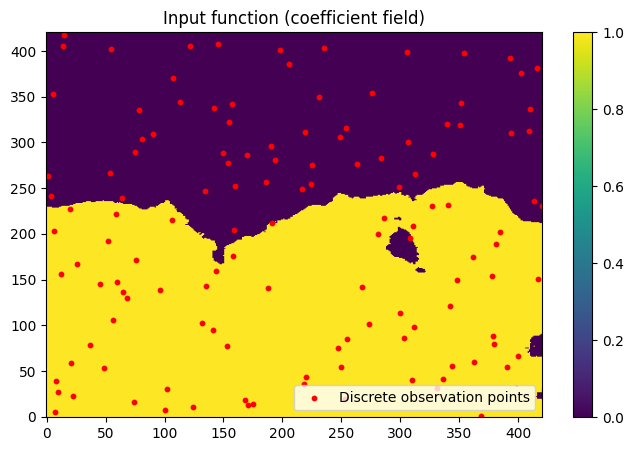

/var/folders/18/sfyl058s60v_rpphjzf5rb200000gn/T/ipykernel_6192/3500207411.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


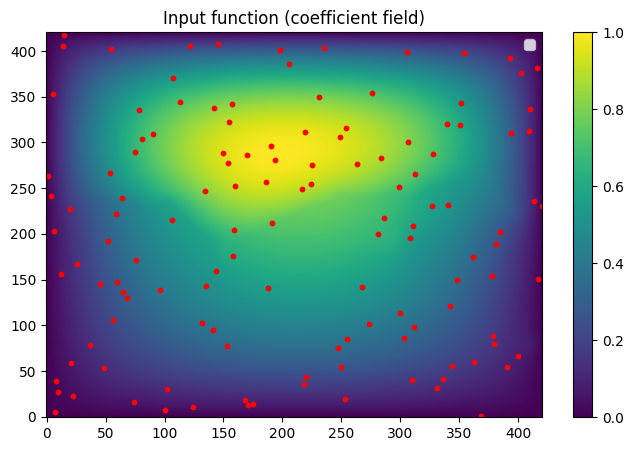

In [31]:
idx = 0
plt.figure(figsize=(8, 5))
plt.imshow(u_cont[idx], aspect='auto', origin='lower')
plt.scatter(x_discrete, y_discrete, color='red', s=10, label='Discrete observation points')
plt.title('Input function (coefficient field)')
plt.colorbar()
plt.legend()
plt.show()

idx = 0
plt.figure(figsize=(8, 5))
plt.imshow(v_cont[idx], aspect='auto', origin='lower')
plt.scatter(x_discrete, y_discrete, color='red', s=10)
plt.title('Input function (coefficient field)')
plt.legend()
plt.colorbar()
plt.show()

In [32]:
N_train = 800
u_cont_train, u_cont_test, v_cont_train, v_cont_test = train_test_split(u_cont, v_cont, train_size=N_train, shuffle = False)
u_train, u_test, v_train, v_test = train_test_split(u, v, train_size=N_train, shuffle = False)
u_train = u_train.reshape(N_train, -1)
v_train = v_train.reshape(N_train, -1)
u_test = u_test.reshape(u_test.shape[0], -1)
v_test = v_test.reshape(v_test.shape[0], -1)

# Encoder-Decoder

## Input

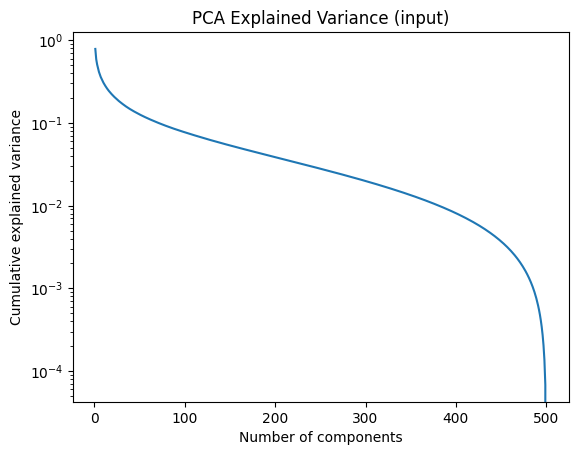

In [33]:
#%% first look at the pca on the input data
n_input = 500
pca_input = PCA(n_components=n_input)
pca_input.fit(u_train)
variance_input = pca_input.explained_variance_ratio_
plt.plot(jnp.arange(n_input) + 1, 1- jnp.cumsum(pca_input.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance (input)')
plt.yscale("log")

## Output

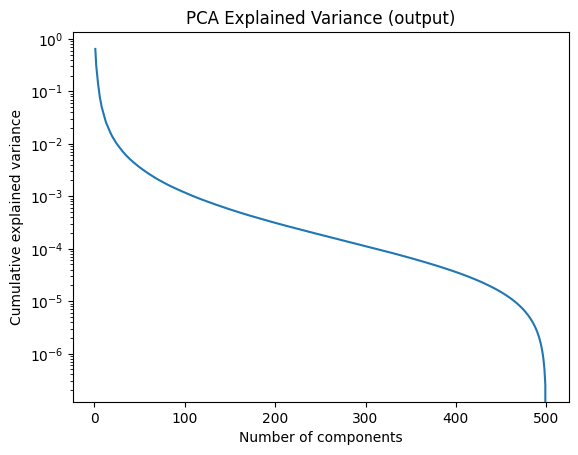

In [34]:
#%% first look at the pca on the input data
n_input = 500
pca_output = PCA(n_components=n_input)
pca_output.fit(v_train)
variance_output = pca_output.explained_variance_ratio_
plt.plot(jnp.arange(n_input) + 1, 1- jnp.cumsum(pca_output.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance (output)')
plt.yscale("log")

# Build a operator 

In [35]:
# Define the encoders
pca_input = PCA(n_components=200)
pca_output = PCA(n_components=200)

u_train_pca = pca_input.fit_transform(u_train)
v_train_pca = pca_output.fit_transform(v_train)

In [36]:

initial_guess = {
    "alpha": 1e-7,
    "length_scale": 1.0,
    "normalize": False,
    "pca_input_components": 30,
    "pca_output_components": 30,
    "weight_matern": 0.5,  
    "nu": "1.5"  # Default value for nu
}

matern_kernel = matern_kernel_create(nu=initial_guess["nu"])  # Default value for nu
def kernel(x,y, param):
    length_scale = param[0]
    weight_matern = param[1]
    weight_dot = 1.0 - weight_matern
    return weight_matern * matern_kernel(x, y, length_scale) + weight_dot * dot_kernel(x, y)


model = BenchmarkGPR(
    kernel=kernel,
    parameters=jnp.array([initial_guess['length_scale'], initial_guess['weight_matern']]),  # Initial guess for length_scale
    alpha= initial_guess['alpha'],
    pca_input_components=initial_guess['pca_input_components'], # does pca under the hood
    pca_output_components = initial_guess['pca_output_components'], # does pca under the hood
    normalize= initial_guess['normalize'],
    jit_kernel=True,
)

In [37]:
#%% Fir the model
model.fit(u_train, v_train)  # Fit the model with the training data and weights if provided

In [38]:
print("Initial cross validation loss ", jnp.mean(cross_val_score(model, u_train, v_train, cv=5, scoring=None)))  # Uses model.score

Initial cross validation loss  0.07658284233674767


# Test set prediction

In [39]:
pred_test = model.predict(u_test)
test_error = relative_l2_loss(v_test, pred_test)
print(f"Test Relative L2 Error: {test_error:.4e}")

Test Relative L2 Error: 7.6571e-02


In [42]:
print(f"Test Relative L2 Error: {test_error:.4e}")

Test Relative L2 Error: 7.6571e-02


In [40]:
# We now define an interpolation function to evaluate the solution at the full grid points
from scipy.interpolate import griddata
idx = 0
pred = model.predict(u_test[idx])
pred_cont = griddata(discrete_points, pred[0].reshape(-1), (X_full, Y_full), method='linear')


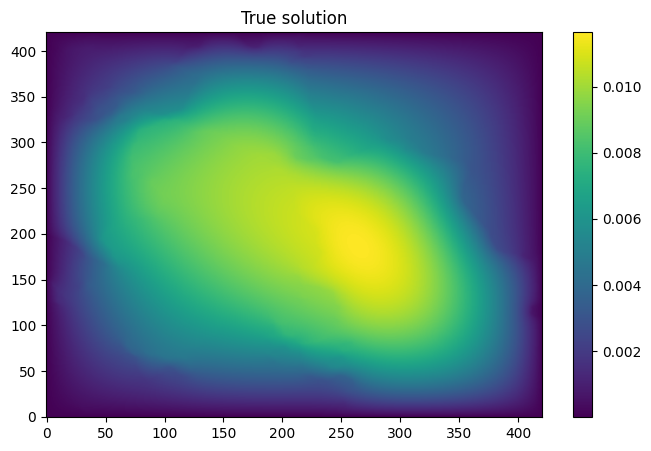

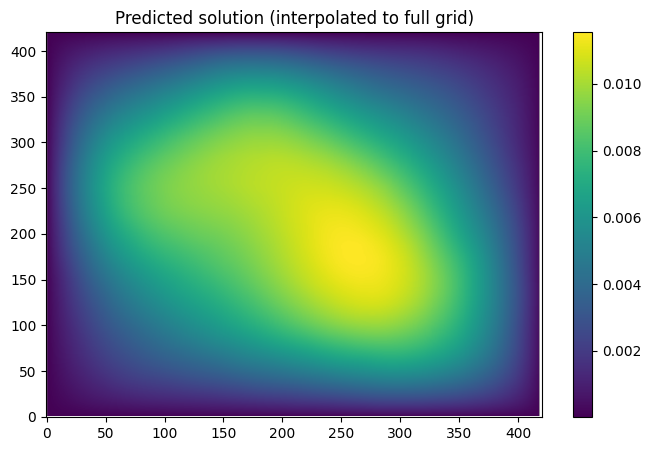

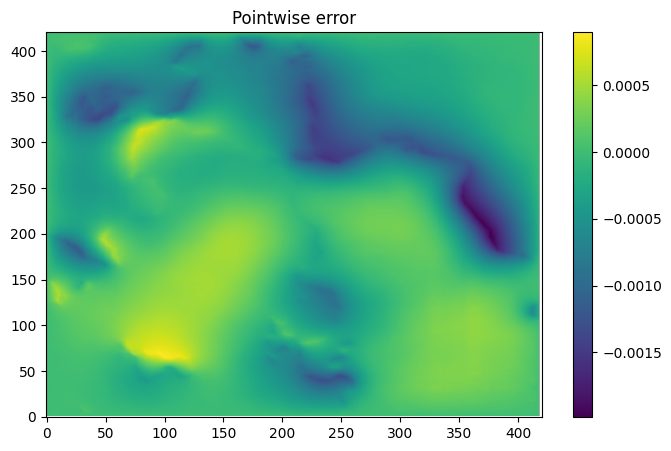

In [41]:
plt.figure(figsize=(8, 5))
plt.imshow(v_cont_test[idx], aspect='auto', origin='lower')
plt.title('True solution')
plt.colorbar()
plt.show()  

plt.figure(figsize=(8, 5))
plt.imshow(pred_cont, aspect='auto', origin='lower')
plt.title('Predicted solution (interpolated to full grid)')
plt.colorbar()
plt.show()  


plt.figure(figsize=(8, 5))
plt.imshow(v_cont_test[idx] - pred_cont, aspect='auto', origin='lower')
plt.title('Pointwise error')
plt.colorbar()
plt.show()  

# Optimize

In [17]:
max_pca_input = 250
max_pca_output = 250
def objective(trial):
    try:
        pca_input_components = trial.suggest_int('pca_input_components', 0, max_pca_input)
        alpha = trial.suggest_float('alpha', 1e-11, 1e0, log=True)
        length_scale = trial.suggest_float('length_scale', 1e-5, 1e5, log=True)
        normalize = trial.suggest_categorical('normalize', [True, False])
        pca_output_components = trial.suggest_int('pca_output_components', 0, max_pca_output)
        weight_matern = trial.suggest_float('weight_matern', 0.0, 1.0)
        nu = trial.suggest_categorical('nu', ['0.5', '1.5', '2.5', 'inf'])

        parameters = jnp.array([length_scale, weight_matern])
        matern_kernel = matern_kernel_create(nu=nu)  # Create the Matern kernel with the suggested nu

        def kernel(x,y, param):
            length_scale = param[0]
            weight_matern = param[1]
            weight_dot = 1.0 - weight_matern
            return weight_matern * matern_kernel(x, y, length_scale) + weight_dot * dot_kernel(x, y)


        model = BenchmarkGPR(
            kernel=kernel,
            parameters=parameters,
            alpha=alpha,
            normalize=normalize,
            pca_input_components=pca_input_components,
            pca_output_components=pca_output_components,
        )

        score = cross_val_score(model, u_train, v_train, cv=5, scoring = None)  # Uses model.score
        score = jnp.mean(score)
        if jnp.isnan(score) or jnp.isinf(score):
            return jnp.inf
        return score

    except Exception as e:
        print(f"Trial failed with error: {e}")
        return jnp.inf

In [18]:
initial_guess = {
    "alpha": 1e-8,
    "length_scale": 1.0,
    "normalize": False,
    "pca_input_components": 20,
    "pca_output_components": 20,
    "weight_matern": 0.5,  
    "nu": "1.5",  # Default value for nu
}

n_trials = 25
study = optuna.create_study(
    sampler=optuna.samplers.TPESampler(seed=42),
    direction="minimize",
    load_if_exists=False,   # lets you resume from the same DB
)
# Add initial guess as first trial
study.enqueue_trial(initial_guess)
study.optimize(objective, n_trials=n_trials)  # Optimize hyper-parameters

[I 2026-03-02 08:53:06,908] A new study created in memory with name: no-name-6571af7f-9c3c-4d04-9271-3dc116a4cfef
[I 2026-03-02 08:53:10,589] Trial 0 finished with value: 0.07832548433693635 and parameters: {'pca_input_components': 20, 'alpha': 1e-08, 'length_scale': 1.0, 'normalize': False, 'pca_output_components': 20, 'weight_matern': 0.5, 'nu': '1.5'}. Best is trial 0 with value: 0.07832548433693635.
[I 2026-03-02 08:53:14,542] Trial 1 finished with value: 0.05936681586065412 and parameters: {'pca_input_components': 94, 'alpha': 0.28698379250004885, 'length_scale': 208.9004704926666, 'normalize': True, 'pca_output_components': 39, 'weight_matern': 0.05808361216819946, 'nu': '0.5'}. Best is trial 1 with value: 0.05936681586065412.
[I 2026-03-02 08:53:18,389] Trial 2 finished with value: inf and parameters: {'pca_input_components': 243, 'alpha': 0.014350566608281143, 'length_scale': 0.001328590390054419, 'normalize': False, 'pca_output_components': 76, 'weight_matern': 0.5247564316322

In [19]:
print("Best trial:")
print("  Value: {}".format(study.best_trial.value))
print("  Params: ")
for key, value in study.best_trial.params.items():
    print("    {}: {}".format(key, value))


Best trial:
  Value: 0.03477665113957056
  Params: 
    pca_input_components: 136
    alpha: 1.7106566316094047e-11
    length_scale: 79.23265948643116
    normalize: True
    pca_output_components: 175
    weight_matern: 0.7364641070684462
    nu: inf


In [20]:
#%% Fit the model with the best parameters
best_params = study.best_trial.params
nu = best_params['nu']
matern_kernel = matern_kernel_create(nu=nu)  # Create the Matern kernel with the best nu
def kernel(x,y, param):
    length_scale = param[0]
    weight_matern = param[1]
    weight_dot = 1.0 - weight_matern
    return weight_matern * matern_kernel(x, y, length_scale) + weight_dot * dot_kernel(x, y)

parameters = jnp.array([best_params['length_scale'], best_params['weight_matern']])
best_params["parameters"] = list([best_params['length_scale'], best_params['weight_matern']])
model = BenchmarkGPR(
    kernel = kernel,
    alpha=best_params['alpha'],
    parameters=parameters,
    normalize=best_params['normalize'],
    pca_input_components=best_params['pca_input_components'],
    pca_output_components=best_params['pca_output_components'],
)

model.fit(u_train, v_train)  # Fit the model with the training data and weights if provided

# Test set prediction

In [23]:
pred_test = model.predict(u_test)
test_error = relative_l2_loss(v_test, pred_test)
print(f"Test Relative L2 Error: {test_error:.4e}")

Test Relative L2 Error: 3.2292e-02


In [24]:
# We now define an interpolation function to evaluate the solution at the full grid points
from scipy.interpolate import griddata
idx = 0
pred = model.predict(u_test[idx])
pred_cont = griddata(discrete_points, pred[0].reshape(-1), (X_full, Y_full), method='linear')


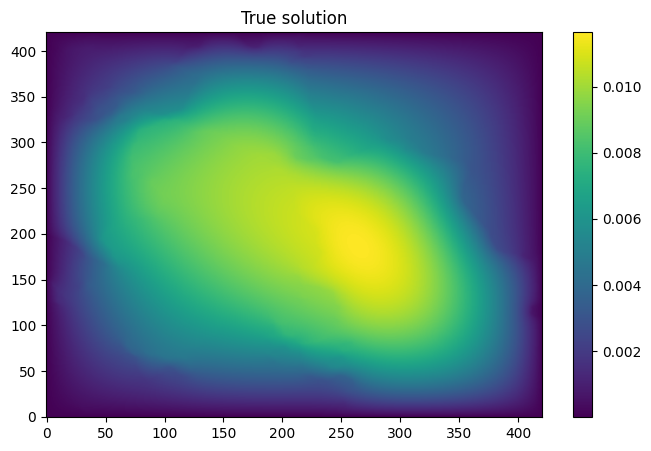

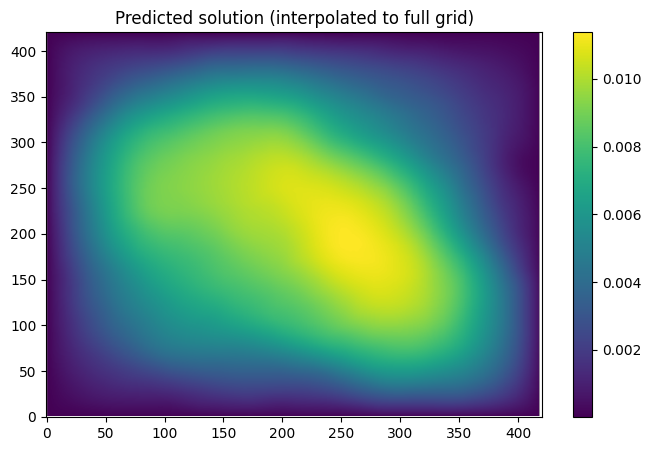

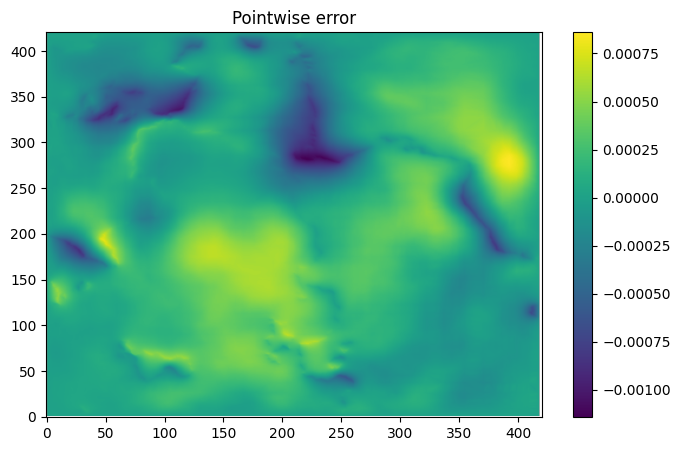

In [25]:
plt.figure(figsize=(8, 5))
plt.imshow(v_cont_test[idx], aspect='auto', origin='lower')
plt.title('True solution')
plt.colorbar()
plt.show()  

plt.figure(figsize=(8, 5))
plt.imshow(pred_cont, aspect='auto', origin='lower')
plt.title('Predicted solution (interpolated to full grid)')
plt.colorbar()
plt.show()  


plt.figure(figsize=(8, 5))
plt.imshow(v_cont_test[idx] - pred_cont, aspect='auto', origin='lower')
plt.title('Pointwise error')
plt.colorbar()
plt.show()  